In [17]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [19]:
df = pd.read_csv("data/Mall_Customers.csv")


In [21]:
df.head()

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Dataset Shape: (200, 5)

Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows:
0


In [23]:
features = [
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features].copy()

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [25]:
print("Feature Shape:", X.shape)

Feature Shape: (200, 2)


In [27]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [29]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

X_scaled_df.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


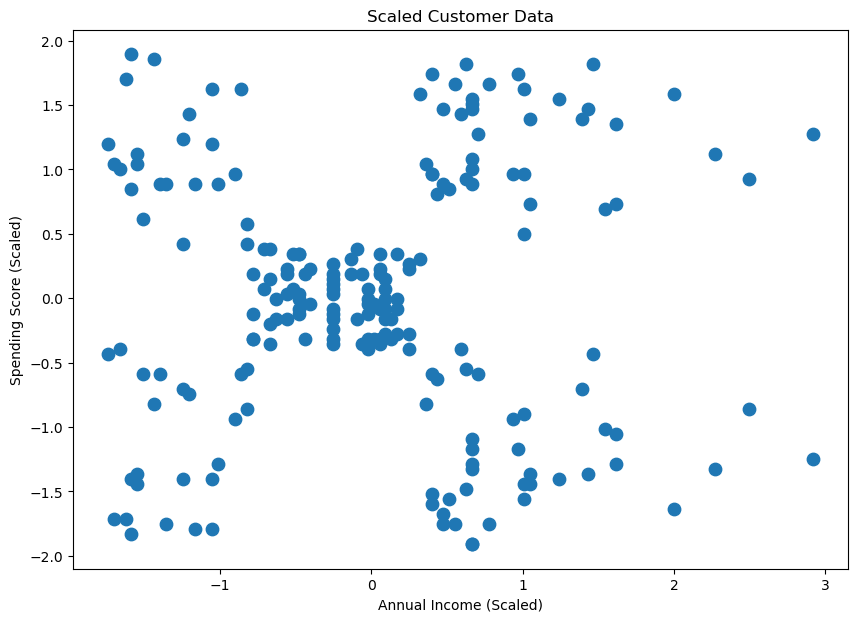

In [31]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_scaled_df["Annual Income (k$)"],
    X_scaled_df["Spending Score (1-100)"],
    s=80
)

plt.title("Scaled Customer Data")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")

plt.show()

In [33]:
inertia_values = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia_values.append(kmeans.inertia_)

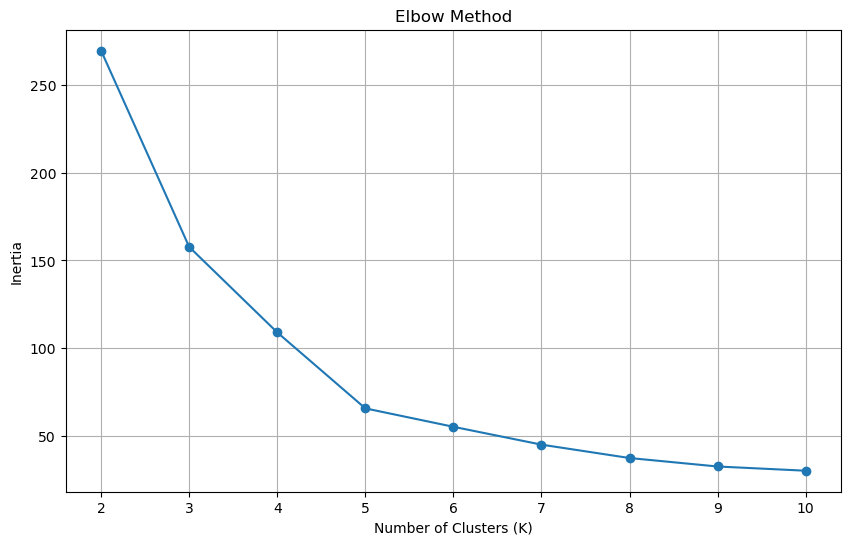

In [35]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    inertia_values,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [37]:
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        labels
    )
    
    silhouette_scores.append(score)

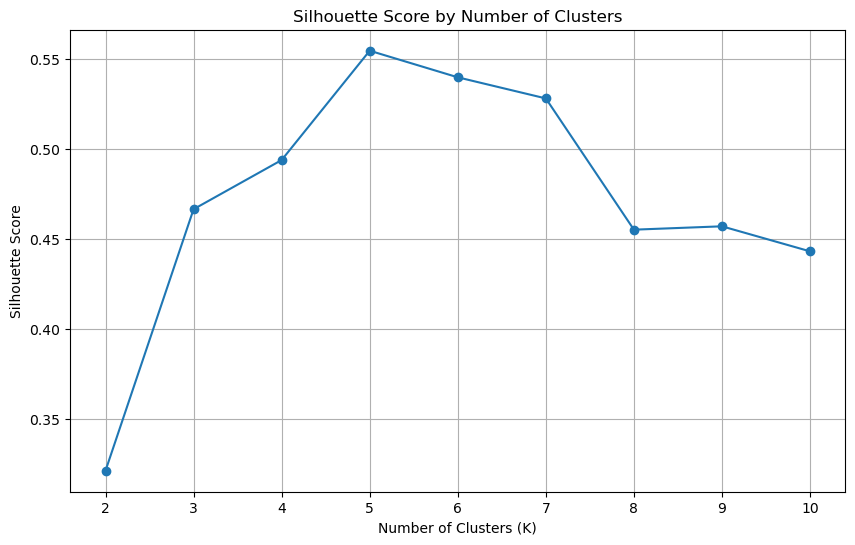

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [41]:
best_index = np.argmax(silhouette_scores)

best_k = list(k_values)[best_index]
best_score = silhouette_scores[best_index]

print("Best K:", best_k)
print("Best Silhouette Score:", round(best_score, 4))

Best K: 5
Best Silhouette Score: 0.5547


In [43]:
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

In [45]:
cluster_labels[:20]

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2],
      dtype=int32)

In [47]:
df["Cluster"] = cluster_labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [49]:
cluster_counts = df["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


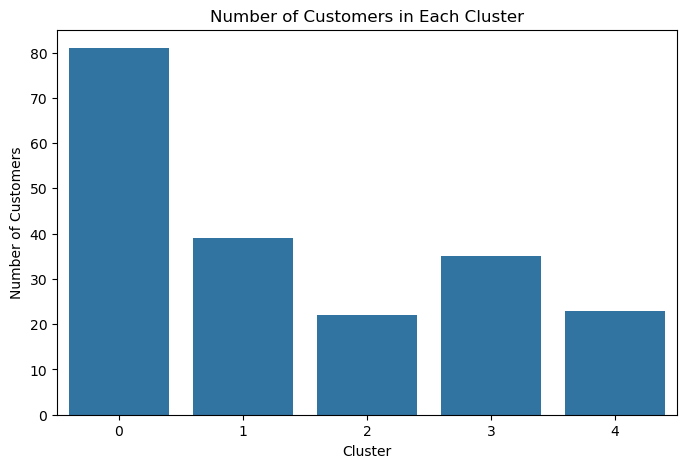

In [51]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Cluster"
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

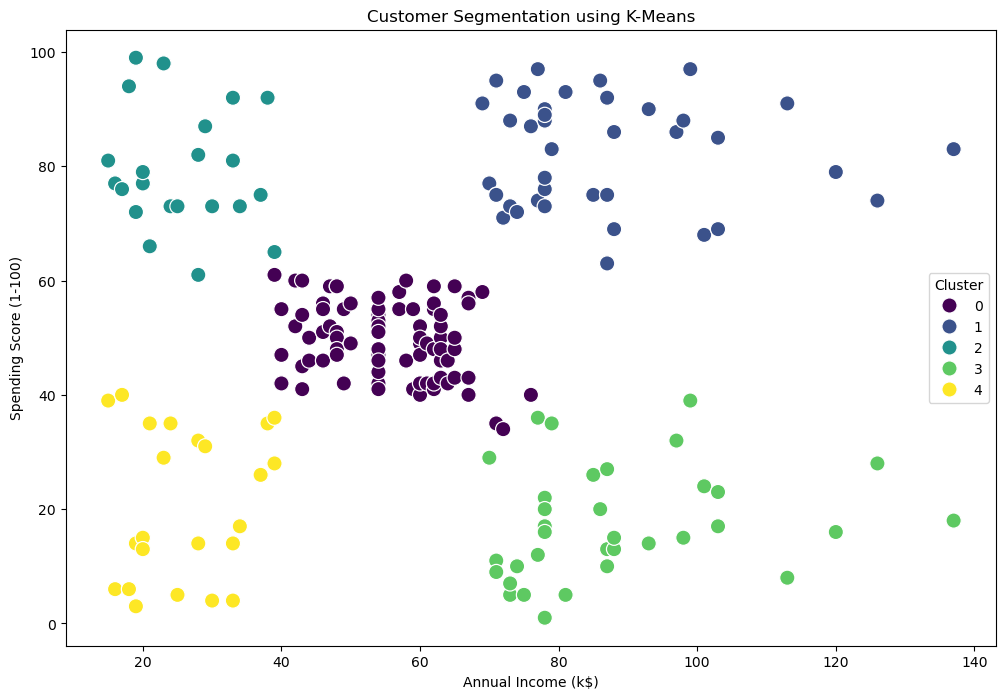

In [53]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="viridis",
    s=120
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.legend(title="Cluster")

plt.show()

In [55]:
centroids_scaled = final_kmeans.cluster_centers_

centroids_scaled

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

In [57]:
centroids_original = scaler.inverse_transform(
    centroids_scaled
)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=features
)

centroids_df

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


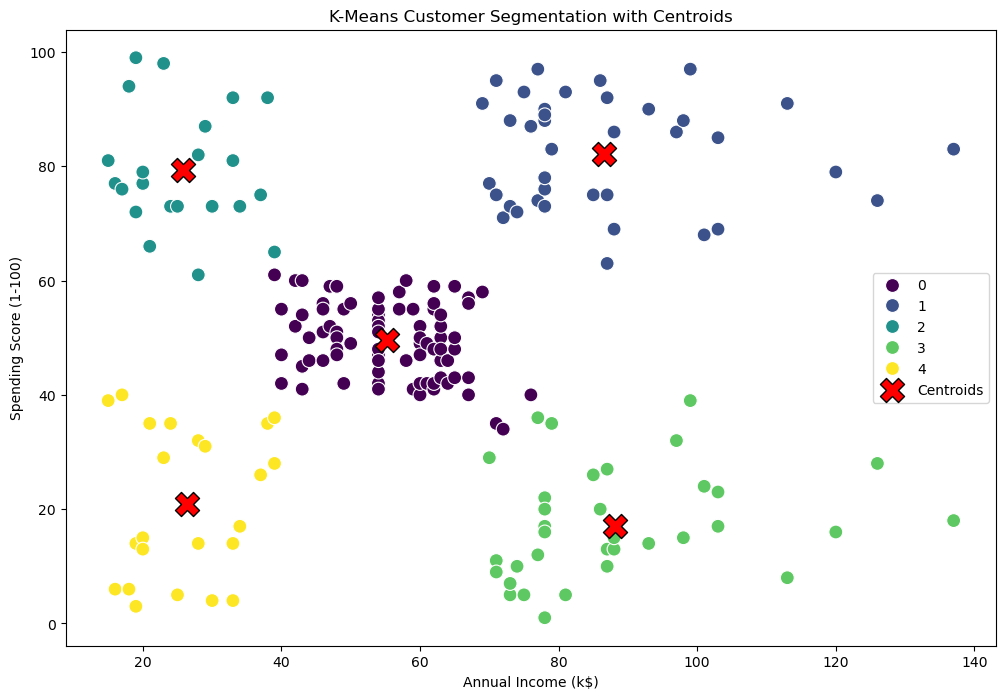

In [59]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="viridis",
    s=100
)

plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    marker="X",
    s=300,
    c="red",
    edgecolor="black",
    label="Centroids"
)

plt.title("K-Means Customer Segmentation with Centroids")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.legend()

plt.show()

In [61]:
cluster_profile = df.groupby("Cluster")[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean().round(2)

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


In [63]:
cluster_profile = df.groupby("Cluster").agg(
    Customer_Count=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending=("Spending Score (1-100)", "mean")
).round(2)

cluster_profile

,Customer_Count,Average_Age,Average_Income,Average_Spending
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


In [65]:
gender_cluster = pd.crosstab(
    df["Cluster"],
    df["Gender"]
)

gender_cluster

Gender,Female,Male
Cluster,,
0,48,33
1,21,18
2,13,9
3,16,19
4,14,9


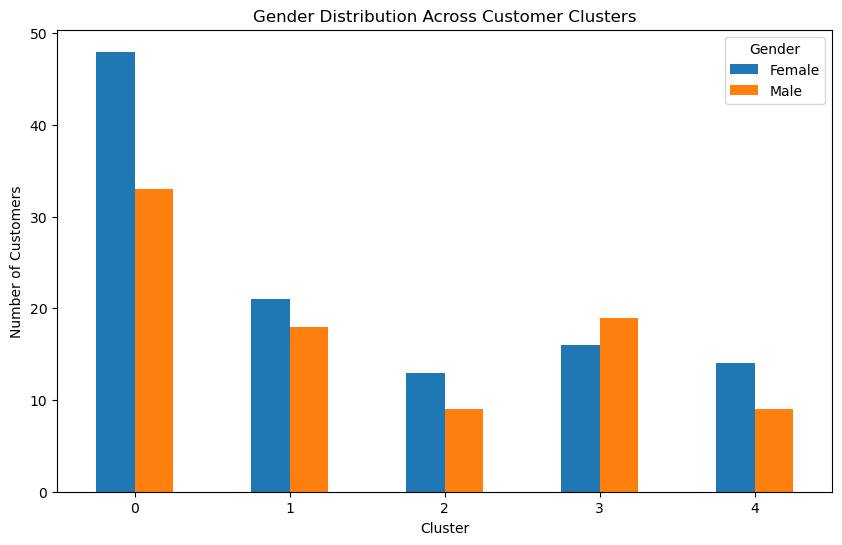

In [67]:
gender_cluster.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Gender Distribution Across Customer Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()

In [69]:
final_silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print(
    "Final Silhouette Score:",
    round(final_silhouette, 4)
)

Final Silhouette Score: 0.5547


In [71]:
cluster_summary = df.groupby("Cluster").agg(
    Customer_Count=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending=("Spending Score (1-100)", "mean")
).round(2)

cluster_summary

,Customer_Count,Average_Age,Average_Income,Average_Spending
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


In [73]:
cluster_summary.sort_values(
    "Average_Spending",
    ascending=False
)

,Customer_Count,Average_Age,Average_Income,Average_Spending
Cluster,,,,
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
0,81,42.72,55.30,49.52
4,23,45.22,26.30,20.91
3,35,41.11,88.20,17.11


In [75]:
final_silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print("Final Silhouette Score:", round(final_silhouette, 4))

Final Silhouette Score: 0.5547


In [77]:
import os

print(os.path.exists("../outputs/results/kmeans_customer_segments.csv"))
print(os.path.exists("../outputs/results/kmeans_cluster_summary.csv"))


False
False


In [79]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
.


In [85]:
df.to_csv(
    "outputs/results/kmeans_customer_segments.csv",
    index=False
)

print("Customer segments saved successfully.")

Customer segments saved successfully.


In [87]:
cluster_summary.to_csv(
    "outputs/results/kmeans_cluster_summary.csv"
)

print("Cluster summary saved successfully.")

Cluster summary saved successfully.


In [89]:
import os

print(
    "Customer segments:",
    os.path.exists("outputs/results/kmeans_customer_segments.csv")
)

print(
    "Cluster summary:",
    os.path.exists("outputs/results/kmeans_cluster_summary.csv")
)

Customer segments: True
Cluster summary: True


In [91]:
import joblib

joblib.dump(
    final_kmeans,
    "models/kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "models/kmeans_scaler.pkl"
)

print("K-Means model and scaler saved successfully.")

K-Means model and scaler saved successfully.


In [93]:
print(
    "K-Means model:",
    os.path.exists("models/kmeans_model.pkl")
)

print(
    "Scaler:",
    os.path.exists("models/kmeans_scaler.pkl")
)

K-Means model: True
Scaler: True
